# IOCL RO Safety — Semantic Risk Classification (v2: Cross-Validated)
**BERT + Classical ML, evaluated with GroupKFold**

This is the hardened version of the training notebook. What changed vs v1:
- **5-fold GroupKFold** cross-validation instead of a single split → the "best model" is robust, reported as **mean ± std**.
- **XGBoost added** → five models compared, not four.
- BERT encoding done **once** and reused across folds.
- **Macro-F1 + per-class report** (classes are imbalanced; accuracy alone misleads).
- Baselines (keyword, TF-IDF) evaluated under the **same** CV for a fair comparison.
- The saved `.pkl` is a **usable bundle** (classifier + encoder name + labels) with a `predict_risk()` helper.

> First: **Runtime → Change runtime type → T4 GPU → Save**, then run top to bottom.

## STEP 0 — Setup

In [1]:
!pip install -q sentence-transformers scikit-learn xgboost pandas numpy matplotlib seaborn
print('Libraries installed.')

Libraries installed.


In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from sentence_transformers import SentenceTransformer
print('Imports ready.')

Imports ready.


## STEP 1 — Upload the dataset
Upload **IOCL_Remarks_ML_Expanded.csv**.

In [3]:
df = pd.read_csv('IOCL_Remarks_ML_Expanded.csv')
print(f'Rows: {len(df):,} | Unique remarks: {df["remark"].nunique():,} | Groups: {df["remark_group"].nunique():,}')
df.head()

Rows: 12,473 | Unique remarks: 12,473 | Groups: 559


,remark_group,item_id,response,remark,risk_level,risk_category
0,GRP0000,A1,Yes,All workers found wearing ISI marked helmets w...,Low,PPE
1,GRP0000,A1,Yes,All workers found wearing ISI marked helmets w...,Low,PPE
2,GRP0000,A1,Yes,Found that all workers found wearing ISI marke...,Low,PPE
3,GRP0000,A1,Yes,"On site visit, all workers found wearing ISI m...",Low,PPE
4,GRP0000,A1,Yes,"At time of inspection, all workers found weari...",Low,PPE


## STEP 2 — Explore (class balance matters for metric choice)

risk_level
Low       5426
High      3684
Medium    3363
Name: count, dtype: int64


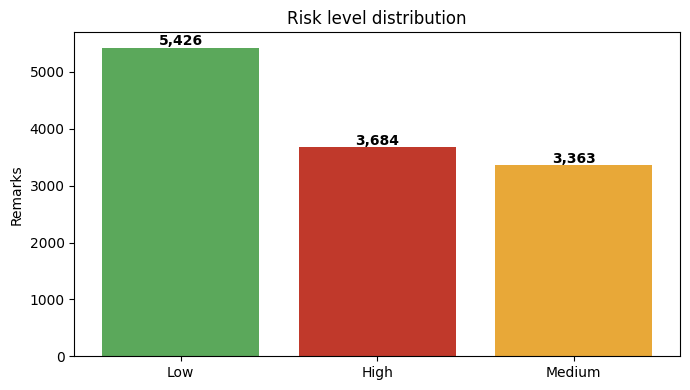

In [4]:
print(df['risk_level'].value_counts())
counts = df['risk_level'].value_counts()
colors = {'Low':'#5BA85B','Medium':'#E8A838','High':'#C0392B'}
plt.figure(figsize=(7,4))
plt.bar(counts.index, counts.values, color=[colors.get(x,'#888') for x in counts.index])
plt.title('Risk level distribution'); plt.ylabel('Remarks')
for i,v in enumerate(counts.values): plt.text(i, v+40, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

## STEP 3 — Prepare arrays + encode labels
We label-encode the target to integers (XGBoost needs numeric labels; the others accept them too).

In [5]:
X_text = df['remark'].astype(str).values
groups = df['remark_group'].values
le = LabelEncoder()
y = le.fit_transform(df['risk_level'].values)   # 0/1/2
LABELS = list(le.classes_)                       # e.g. ['High','Low','Medium']
print('Label order:', LABELS)

Label order: ['High', 'Low', 'Medium']


## STEP 4 — Encode every remark with BERT ONCE
BERT is the slow part. We encode all remarks a single time into 384-dim vectors and reuse
those vectors across all CV folds. BERT here is only the *encoder* — it turns text into meaning-vectors;
the classifiers below do the actual Low/Medium/High decision.

In [6]:
bert = SentenceTransformer('all-MiniLM-L6-v2')
X_emb = bert.encode(X_text.tolist(), show_progress_bar=True, batch_size=64)
print('Embeddings:', X_emb.shape)   # (n_remarks, 384)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

d:\Anaconda\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Shrish Singh Sourya\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/195 [00:00<?, ?it/s]

Embeddings: (12473, 384)


## STEP 5 — The five models

In [7]:
def make_models():
    return {
        'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
        'SVM (rbf)':           SVC(kernel='rbf', random_state=42),
        'Random Forest':       RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42),
        'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
        'XGBoost':             XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                                             subsample=0.9, colsample_bytree=0.9,
                                             tree_method='hist', eval_metric='mlogloss',
                                             verbosity=0, random_state=42),
    }

## STEP 6 — 5-fold GroupKFold cross-validation on the BERT embeddings
Each fold holds out whole `remark_group`s, so no phrasing leaks across train/test.
We report **accuracy** and **macro-F1** as mean ± std over the 5 folds.

In [8]:
gkf = GroupKFold(n_splits=5)
cv_rows = []
for name in make_models():
    accs, f1s = [], []
    for tr, te in gkf.split(X_emb, y, groups):
        m = make_models()[name]
        m.fit(X_emb[tr], y[tr])
        p = m.predict(X_emb[te])
        accs.append(accuracy_score(y[te], p))
        f1s.append(f1_score(y[te], p, average='macro'))
    cv_rows.append({'Model': f'BERT + {name}',
                    'Acc mean': np.mean(accs)*100, 'Acc std': np.std(accs)*100,
                    'MacroF1 mean': np.mean(f1s)*100, 'MacroF1 std': np.std(f1s)*100})
    print(f'{name:20s}  acc {np.mean(accs)*100:5.1f}±{np.std(accs)*100:.1f}   '
          f'macroF1 {np.mean(f1s)*100:5.1f}±{np.std(f1s)*100:.1f}')

Logistic Regression   acc  79.1±4.7   macroF1  76.8±4.2
SVM (rbf)             acc  75.8±4.1   macroF1  73.3±3.1
Random Forest         acc  59.0±3.7   macroF1  54.1±2.5
Gradient Boosting     acc  68.9±3.2   macroF1  66.2±1.8
XGBoost               acc  73.1±5.7   macroF1  70.2±4.0


## STEP 7 — Baselines under the SAME cross-validation (fair comparison)

In [9]:
# Keyword baseline (deterministic)
hi = ['absent','no ','not ','missing','without','expired','failed','broken','critically','dangerous','immediate','severe','extremely']
md_ = ['but','overdue','low','partially','insufficient','loose','cracked','inadequate','needs','pending','seems','acting']
def kw(r):
    r=r.lower(); h=sum(w in r for w in hi); m=sum(w in r for w in md_)
    lab='High' if h>=2 else ('Medium' if (h>=1 or m>=2) else 'Low')
    return le.transform([lab])[0]

kw_acc, kw_f1, tf_acc, tf_f1 = [], [], [], []
for tr, te in gkf.split(X_text, y, groups):
    pk = np.array([kw(r) for r in X_text[te]])
    kw_acc.append(accuracy_score(y[te], pk)); kw_f1.append(f1_score(y[te], pk, average='macro'))
    vec = TfidfVectorizer(max_features=2000, ngram_range=(1,2), stop_words='english')
    Xt = vec.fit_transform(X_text[tr]); Xv = vec.transform(X_text[te])
    rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42).fit(Xt, y[tr])
    pt = rf.predict(Xv)
    tf_acc.append(accuracy_score(y[te], pt)); tf_f1.append(f1_score(y[te], pt, average='macro'))

cv_rows = [
    {'Model':'Keyword baseline','Acc mean':np.mean(kw_acc)*100,'Acc std':np.std(kw_acc)*100,
     'MacroF1 mean':np.mean(kw_f1)*100,'MacroF1 std':np.std(kw_f1)*100},
    {'Model':'TF-IDF + Random Forest','Acc mean':np.mean(tf_acc)*100,'Acc std':np.std(tf_acc)*100,
     'MacroF1 mean':np.mean(tf_f1)*100,'MacroF1 std':np.std(tf_f1)*100},
] + cv_rows

comp = pd.DataFrame(cv_rows)
comp_disp = comp.copy()
for c in ['Acc mean','Acc std','MacroF1 mean','MacroF1 std']:
    comp_disp[c] = comp_disp[c].map(lambda v: f'{v:.1f}')
print(comp_disp.to_string(index=False))

                     Model Acc mean Acc std MacroF1 mean MacroF1 std
          Keyword baseline     54.1     6.2         51.9         5.8
    TF-IDF + Random Forest     79.2     2.5         77.2         2.8
BERT + Logistic Regression     79.1     4.7         76.8         4.2
          BERT + SVM (rbf)     75.8     4.1         73.3         3.1
      BERT + Random Forest     59.0     3.7         54.1         2.5
  BERT + Gradient Boosting     68.9     3.2         66.2         1.8
            BERT + XGBoost     73.1     5.7         70.2         4.0


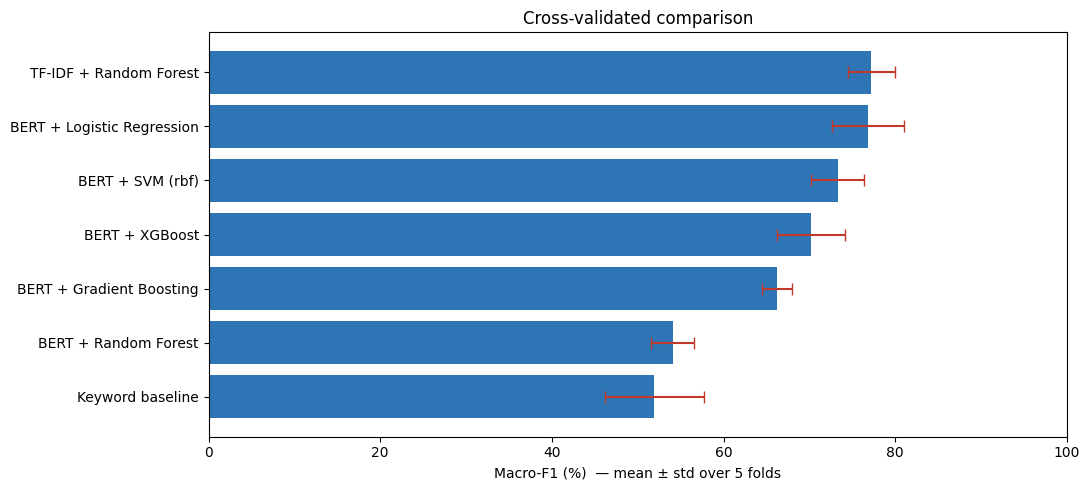

In [10]:
# Plot accuracy with error bars
plt.figure(figsize=(11,5))
order = comp.sort_values('MacroF1 mean')
plt.barh(order['Model'], order['MacroF1 mean'], xerr=order['MacroF1 std'],
         color='#2E75B6', ecolor='#C0392B', capsize=4)
plt.xlabel('Macro-F1 (%)  — mean ± std over 5 folds'); plt.title('Cross-validated comparison')
plt.xlim(0,100); plt.tight_layout(); plt.show()

## STEP 8 — Pick the winner by CV macro-F1, then one clean held-out evaluation
We select the model with the best cross-validated macro-F1, refit it on a group-clean train split,
and report the per-class numbers + confusion matrix on a held-out test set.

Winner by CV macro-F1: BERT + Logistic Regression
              precision    recall  f1-score   support

        High       0.81      0.79      0.80       762
         Low       0.88      0.91      0.90       982
      Medium       0.79      0.77      0.78       741

    accuracy                           0.83      2485
   macro avg       0.83      0.83      0.83      2485
weighted avg       0.83      0.83      0.83      2485



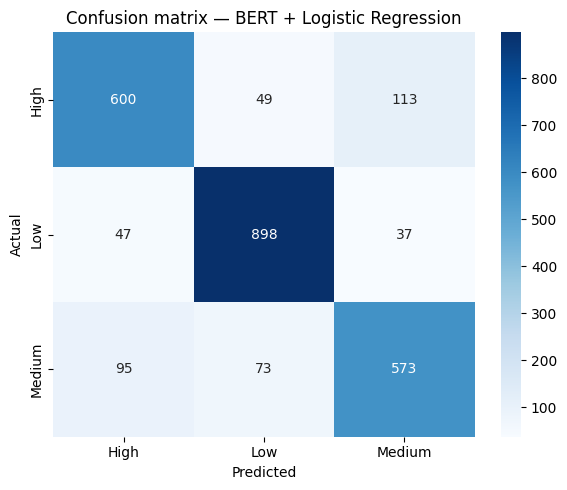

In [11]:
bert_rows = comp[comp['Model'].str.startswith('BERT')]
best_full = bert_rows.loc[bert_rows['MacroF1 mean'].idxmax(), 'Model']
best_name = best_full.replace('BERT + ', '')
print('Winner by CV macro-F1:', best_full)

tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42).split(X_emb, y, groups))
best_model = make_models()[best_name]
best_model.fit(X_emb[tr], y[tr])
pred = best_model.predict(X_emb[te])
print(classification_report(y[te], pred, target_names=LABELS))

cm = confusion_matrix(y[te], pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABELS, yticklabels=LABELS)
plt.title(f'Confusion matrix — {best_full}'); plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

## STEP 9 — Save a USABLE model bundle
v1 saved only the bare classifier, so the pkl couldn't take raw text. Here we save the classifier
*plus* the encoder name and label order, and define a `predict_risk()` helper that wires them together.

In [14]:
import pickle
bundle = {
    'classifier': best_model,
    'encoder_name': 'all-MiniLM-L6-v2',
    'labels': LABELS,
    'embedding_dim': int(X_emb.shape[1]),
    'cv_macro_f1': float(bert_rows['MacroF1 mean'].max()),
}
with open('risk_classifier_bundle.pkl', 'wb') as f:
    pickle.dump(bundle, f)
print('Saved risk_classifier_bundle.pkl')

# --- how to load + use it later ---
_enc = SentenceTransformer(bundle['encoder_name'])
def predict_risk(text):
    v = _enc.encode([text])
    idx = bundle['classifier'].predict(v)[0]
    return bundle['labels'][idx]

Saved risk_classifier_bundle.pkl


## STEP 10 — Sanity test on new remarks (incl. an out-of-distribution one)

In [15]:
for r in [
    'Fire extinguisher present but pressure gauge reading below minimum',
    'All helmets checked and found in good condition',
    'No ELCB installed on main panel, workers exposed to electrocution risk',
    'Safety shoes worn by all staff during inspection',
    'The gauge is acting a bit funny today',            # vague / OOD
    'Extinguisher situation looks bad, needs urgent fixing',
]:
    print(f'[{predict_risk(r):^7}]  {r}')

[Medium ]  Fire extinguisher present but pressure gauge reading below minimum
[Medium ]  All helmets checked and found in good condition
[ High  ]  No ELCB installed on main panel, workers exposed to electrocution risk
[  Low  ]  Safety shoes worn by all staff during inspection
[Medium ]  The gauge is acting a bit funny today
[ High  ]  Extinguisher situation looks bad, needs urgent fixing


## What to tell your guide (accurate framing)
1. The model is selected by **5-fold GroupKFold cross-validation** (macro-F1), so the result isn't an artifact of one lucky split.
2. **Five** algorithms compared, including **XGBoost**; on dense BERT embeddings the linear model competes with or beats the tree ensembles — expected, because tree splits are axis-aligned and BERT meaning is distributed across all 384 dimensions.
3. BERT's value over TF-IDF on this **synthetic** set is modest because the remarks come from a finite template pool; its real advantage is robustness to **unseen, real-world phrasing**.
4. Numbers here are an **optimistic ceiling** relative to genuine field remarks — honest, not overclaimed.